### $p_{mn}$ Standard Expression (Infinite Sum)

The expression for the coincidences probability distribution before any simplifications is 

\begin{equation}
p_{mn}=\frac{1}{ab}\sum_{k=0}^{\infty}\left(\frac{|\gamma|^2}{4ab}\right)^k\ F(-m,k+1,1,\frac{1}{a})F(-n,k+1,1,\frac{1}{b}),
\end{equation}

where $a=\langle N_{s2}^0\rangle+1$ and $b=\langle N_{i2}^0\rangle+1$. Having an infinite sum is undesirable for computation purposes, so a different approach is used (see Prof. Torres' notes)

### $_2F_1(-m,k+1,1,x)$

There's are two different reported expressions for the hypergeometric funtion $_2F_1(-m,k+1,1,x)$. The first one is given as 

\begin{equation}
    _2F_1(-m,k+1,1,x)=\sum_{j=0}^{m}\frac{(-1)^j}{(j!)^2}\frac{m!}{(m-j)!}(k+1)_j\ x^j,
\end{equation}

and it reflects the fact that when the first parameter (usually identified as $\alpha$) is negative (in this case $-m$), the hypergeometric is a polynomial in $x$. In this expression, the term $(k+1)_j$ represents the Pochhammer symbol 

\begin{equation}
(k+1)_j=(1)(1+k)(2+k)\cdots(j+k),
\end{equation}

with $(k+1)_0=1$. $(k+1)_j$ is a j-th order polynomial in $k$, whose coefficients can be derived from the roots $(-1,-2,\cdots,-j)$ via the function $polyfromroots$. Rewritting, we obtain 

\begin{equation}
    _2F_1(-m,k+1,1,x)=\sum_{j=0}^{m}\left(\frac{(-1)^j}{(j!)^2}\frac{m!}{(m-j)!}x^j\right)\ (k+1)_j,
\end{equation}

where it's possible to clearly appreciate that each term of the sum is a j-th order polynomial in k multiplied by a coefficient $C_j=\frac{(-1)^j}{(j!)^2}\frac{m!}{(m-1)!}x^j$. 

Consequently, the other given expression for the hypergeometric function is a polynomial in k.  

\begin{equation}
    _2F_1(-m,k+1,1,x)=\sum_{j=0}^{m}r_j^m(x)k^j,
\end{equation}

There's no closed analytical expression for the coefficients $r_j^m(x)$, which makes this a less atractive option to compute the hypergeomretic function. Nevertheless, the ultimate goal is to compute the probability distribution $p_{mn}$, which can be done through an expression that contains the coefficients $r_j^m(x)$ (see notes). Because of this, it is of interest to develop a function that can compute any of this coefficients.

Such is the case of the python function r_m(m,x) presented below. It receives the arguments $m$ and $x$, which are an integer and a vector, respectively. The output has the an structure

\begin{equation}
r_m(m,x)=
    \begin{bmatrix}
    r_0^m(x1) & r_0^m(x2) & \cdots & r_0^m(x_t) \\
    r_1^m(x1) & r_1^m(x2) & \cdots & r_1^m(x_t) \\
    \vdots    & \vdots    & \ddots & \vdots     \\
    r_m^m(x1) & r_m^m(x2) & \cdots & r_m^m(x_t)
    \end{bmatrix}
\end{equation}

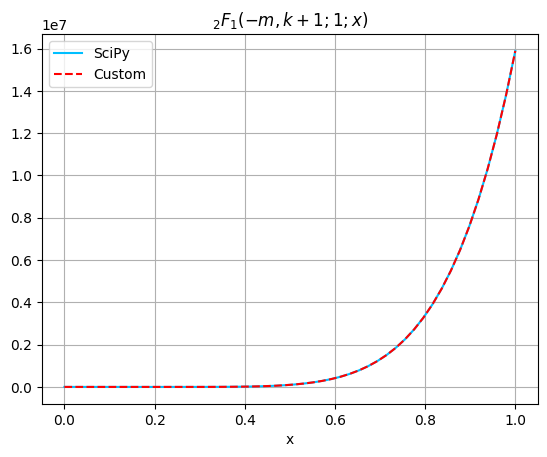

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfromroots
from scipy.special import factorial, hyp2f1

def r_m(m,x):
    j=np.arange(m+1).reshape((m+1,1,1))   # 1D Vector --> 3D 'Columns'
    Cj=(-1)**j/factorial(j)**2*factorial(m)/factorial(m-j)*x**j
    polys=np.zeros((m+1,m+1,1))     # Empty Matrix that will hold the coefficients
    for i in range(m+1):
        roots=-np.r_[1:i+1]
        polys[i,0:i+1,0]=polyfromroots(roots)
    r=Cj*polys
    return np.sum(r, axis=0)

k=50
m=6
x=np.linspace(0,1)

### Scipy
y=hyp2f1(-m,k+1,1,x)

### Custom 
j=np.c_[0:m+1]
y2=np.sum(r_m(m,x)*k**j,axis=0)

### Visual Comparisson
fig,ax=plt.subplots()
ax.plot(x,y,color="deepskyblue",label="SciPy")
ax.plot(x,y2,color="red",label="Custom",linestyle="--")
ax.grid(True)
ax.set_xlabel("x")
ax.set_title(r"$_2F_1(-m,k+1;1;x)$")
ax.legend()

### $p_{mn}$ Simplified Expression (Finite Sum)

The coincidences probability distribution can be simplified and rewritten as

\begin{equation}
    p_{mn}=\frac{1}{ab}\sum_{l=0}^{m+n}\sum_{j=0}^{l}\ r_{j}^{m}(a) r_{l-j}^{n}(b)f_l(x),
\end{equation}

where the coefficients $r^u_d(x)=0$ whenever $d>u$. The functions $f_l(x)$ are given by the recursive formula 

\begin{equation}
    f_{n+1}=x\ \frac{\mathrm{d}}{\mathrm{d}x}f_n(x),
\end{equation}

\begin{equation}
    f_{0}=\frac{1}{1-x}.
\end{equation}

However, in order to avoid numerical derivation, it is also to possible to write these functions in terms of polynomials $Q_n(x)$ of order $n$. This will improve the precision, since even though there's still a derivative in the polynomials recursion formula, the derivative of the polynomials can be taken by analytically finding the coefficients and then calling a polival function. This is the method employed here to implement the computatation of the functions $f_n(x)$

\begin{equation}
    f_n=\frac{Q_n(x)}{(1-x)^{n+1}},
\end{equation}

where

\begin{equation}
    Q_n=x\cdot\left\{(1-x)\frac{\mathrm{d}Q_{n-1}(x)}{\mathrm{d}x}+n\cdot Q_{n-1}(x)\right\},
\end{equation}

with $Q_0=1$. While it is possible to implement a recursive function in python that computes $f_l(x)$ given $l$ and $x$ as parameters, this will not be convinient for the purpose of computing the probability distribution, since calling this function for each new value of $l$ inside a loop would require to do the recursion routine each time anew. Because of this, it is better to simply perform the recursion routine once, up until the maximum value of $l$, and store each step of the recursion. This way, the whole cycle only has to be done only once.

Below, the function $f_{all}(n_{max},x)$ computes all the functions $f_n(x)$ up to the indicated $f_{n_{max}}(x)$, and ir returns an array $f$ of dimensions $(n_{max}+1,x.size)$ that contains the numerically evaluated $f_n(x)$ in the n-th row $f[n,:]$.
The function also computes and stores the coefficients of the polynomial Q_n, in case it is necessary to validate. However, the function needs to be modified to add the coefficients L to the output.

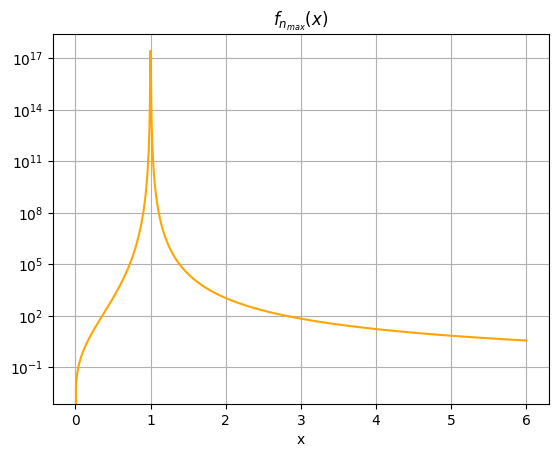

In [2]:
from numpy.polynomial.polynomial import polyval,polyadd,polymul,polymulx,polypow,polyder
    
def f_all(n_max,x):
    f=np.zeros([n_max+1,np.array(x).size])
    f[0,:]=1/(1-x)
    Q=[np.array([1])]
    for n in range(1,n_max+1):
        Q.append(
            polymulx(polyadd(polymul(np.array([1,-1]),polyder(Q[n-1])),n*Q[n-1]))
        )
        f[n,:]=polyval(x,Q[n])/polyval(x,polypow([1,-1],n+1))
    return f

n_max=5
x=np.linspace(0,6,1000)
f=f_all(n_max,x)

fig,ax=plt.subplots()
ax.plot(x,f[n_max,:],color="orange")
ax.set_xlabel("x")
ax.set_title(r"$f_{n_{max}}(x)$")
ax.grid(True)
ax.set_yscale("log")

As mentioned before, the coincidences probability distribution can be also written as 

\begin{equation}
    p_{mn}=\frac{1}{ab}\sum_{l=0}^{m+n}\sum_{j=0}^{l}\ r_{j}^{m}(a) r_{l-j}^{n}(b)f_l(x).
\end{equation}

Functions to compute both $r_{j}^{m}(a)$ and $f_l(x)$ have been introduced already. This expression promises to have the advantage of involving a finite sum, instead of an infinite one. However it is important to keep in mind that the ultimate goal is to compute the Fisher Information, which involves a sum over $m$ and $n$. In principle, it is not known how many terms will be necessary for the sum of probabilities $p_{mn}$ to be equal to one, which means that it is necessary to compute $p_{mn}$ inside a loop, not knowing how many iterations will be necessary to conclude the loop. In order to compare which expression for the probabilty distribution will perform better, it is necessary to take into account that the variables $m$ and $n$ will NOT be arrays.


Ellapsed time: 0.5762069225311279


Text(0.5, 0, 'p')

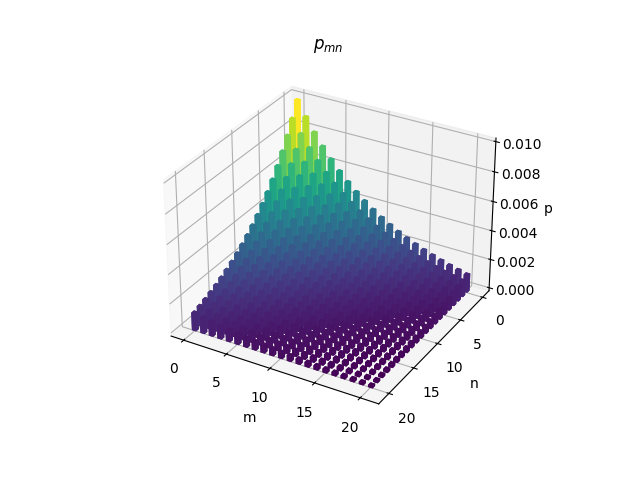

In [3]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyval,polyadd,polymul,polymulx,polypow,polyder,polyfromroots
import time
from mpl_toolkits.mplot3d import axes3d


def r_m(m,x):
    j=np.arange(m+1).reshape((m+1,1,1))   # Sheets --> 3D
    Cj=(-1)**j/factorial(j)**2*factorial(m)/factorial(m-j)*x**j
    polys=np.zeros((m+1,m+1,1))
    for i in range(m+1):
        roots=-np.r_[1:i+1]
        polys[i,0:i+1,0]=polyfromroots(roots)
    r=Cj*polys
    return np.sum(r, axis=0)

def f_all(n_max,x):
    f=np.zeros([n_max+1,np.array(x).size])
    f[0,:]=1/(1-x)
    Q=[np.array([1])]
    for n in range(1,n_max+1):
        Q.append(
            polymulx(polyadd(polymul(np.array([1,-1]),polyder(Q[n-1])),n*Q[n-1]))
        )
        f[n,:]=polyval(x,Q[n])/polyval(x,polypow([1,-1],n+1))
    return f

def p_alt(m,n,a,b,x):
    "a,b,x are meant to have the same dimensions."
    "Compute the p_mn for a single combination (m,n)"
    p=0
    rm=r_m(m,1/a)
    rn=r_m(n,1/b)
    f=f_all(m+n,x)
    for l in range(m+n+1):
        for j in range(l+1):
            if j<=m and (l-j)<=n:
                p+=rm[j,0]*rn[l-j,0]*f[l,0]
            else: 
               continue
    return 1/(a*b)*p

max_m=20
a,b=10,10
x=1/(4*a*b)

p=np.zeros((max_m+1,max_m+1))
t1=time.time()
for i in range(max_m+1):
    for j in range(max_m+1):
       p[i,j]=p_alt(i,j,a,b,x)
t2=time.time()
print("Ellapsed time:",(t2-t1))

i,j = np.meshgrid(np.arange(max_m+1),np.arange(max_m+1),indexing="ij")
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
xpos = i.ravel()
ypos = j.ravel()
bars = p.ravel()
colors = plt.cm.viridis((bars - bars.min()) / (bars.max() - bars.min()))
ax.bar3d(xpos,ypos,0,0.5,0.5,bars,shade=False,color=colors)
ax.set_title(r"$p_{mn}$")
ax.set_xlabel("m")
ax.set_ylabel("n")
ax.yaxis.set_inverted(True)
ax.set_zlabel("p")